# Reprogramming Case 01: Cardiac Inhibition Analysis with Navigo

This notebook uses Navigo to analyze why fibroblast-to-cardiomyocyte conversion remains inefficient even when cardiac transcription-factor programs are activated.

Model note: **`checkpoint_cardiac_repro` is trained on fibroblasts and cardiomyocytes together**, so the learned dynamics focus on fibroblast-to-cardiac state transitions.

In this notebook you will:
- Use fibroblasts as the source state and cardiomyocytes as the target fate.
- Simulate regulator-level perturbations and track downstream transcriptomic responses.
- Reconstruct a three-layer regulatory cascade linking cardiac TFs, pro-fibrotic intermediates, and cardiac structural genes.
- Use that network to identify inhibitory programs that may oppose cardiac maturation.

Import packages and set deterministic seeds.

In [1]:
import os
import sys
from pathlib import Path

import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import torch

plt.rcParams['font.style'] = 'italic'
plt.rcParams['figure.dpi'] = 120
np.random.seed(0)
torch.manual_seed(0)


Locate repository resources and load Navigo APIs.

Biological context: `checkpoint_cardiac_repro.pth` is the fibroblast+cardiomyocyte trained model, and the fibroblast atlas provides the baseline cellular state from which perturbation responses are simulated.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


cwd = Path.cwd().resolve()
repo_root = find_repo_root(cwd)
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'reprogramming_section'
data_shared_dir = repo_root / 'data' / 'shared'
case_output_root = tutorials_root / 'outputs' / 'reprogramming_cardiac_inhibition'

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from navigo import run_perturbation_inference


Define data inputs and organized output directories for the cardiac inhibition case.

In [3]:
CHECKPOINT_PATH = repo_root / 'checkpoints' / 'reprogramming' / 'cardiac_reprogramming_checkpoint.pth'
DATA_PATH = data_shared_dir / 'mouse_heart_fibroblasts.h5ad'
TARGET_LIST_PATH = data_shared_dir / 'cardiomyocyte_inhibition_targets.csv'

INFERRED_DIR = case_output_root / '01_inference_csv'
FIGURE_DIR = case_output_root / '02_figures'
SUMMARY_DIR = case_output_root / '03_summaries'

INFERRED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

required = {
    'checkpoint': CHECKPOINT_PATH,
    'dataset_h5ad': DATA_PATH,
    'target_list_csv': TARGET_LIST_PATH,
}

missing = [f'{k}: {v}' for k, v in required.items() if not v.exists()]
if missing:
    raise FileNotFoundError('Missing required resources\n' + '\n'.join(missing))


## Step 1: Run perturbation inference

For each candidate regulator, Navigo predicts fibroblast expression shifts after intervention.
We score each candidate by directional consistency with expected fibroblast-to-cardiomyocyte transitions.

In [ ]:
inference_summary = run_perturbation_inference(
    data_path=DATA_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    target_list_path=TARGET_LIST_PATH,
    output_dir=INFERRED_DIR,
    fibro_cell_type='Fibroblasts',
    input_dim=7804,
    hidden_1=5012,
    hidden_2=5012,
    flow_num_steps=100,
    simulation_steps=10,
    knockout_scale=3.0,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    strict_target_presence=False,
)

print(f"Candidate regulators: {len([line for line in TARGET_LIST_PATH.read_text().splitlines() if line.strip()])}")
print(f'Inference output folder: {INFERRED_DIR.relative_to(repo_root)}')
print(f"Generated CSV files: {len(list(INFERRED_DIR.glob('*.csv')))}")


## Build a mechanistic three-layer network

Layers used for interpretation:
- **Layer 1 (cardiac TFs)**: candidate drivers such as Gata4/Mef2c/Esrrg/Hif1a
- **Layer 2 (pro-fibrotic genes)**: inferred intermediates that can counteract conversion
- **Layer 3 (cardiac development genes)**: terminal readouts linked to cardiomyocyte identity

Edge color shows inferred effect direction under perturbation: red = activation, blue = suppression.

In [5]:
TOP_TFS = ['Gata4', 'Mef2c', 'Esrrg', 'Hif1a']
FIBRO_GENES = ['Meox2', 'Igf1', 'Col3a1', 'Hmga2', 'Klf12', 'Bnc2']
CARDI_GENES = ['Sgcd', 'Cacna1c', 'Tgfbr3', 'Nr3c1', 'Adamts9', 'Dlc1']


def collect_edges(folder):
    edges, colors, widths, rows = [], [], [], []

    for tf in TOP_TFS:
        tf_file = folder / f'{tf}.csv'
        if not tf_file.exists():
            continue
        df = pd.read_csv(tf_file)
        for g in FIBRO_GENES:
            hit = df[df['gene_name'] == g]
            if hit.empty:
                continue
            v = float(hit['total_change'].iloc[0])
            edges.append((tf, g))
            colors.append('red' if v > 0 else 'blue')
            widths.append(abs(v) * 1000)
            rows.append({'source': tf, 'target': g, 'layer': 'TF->Fibro', 'total_change': v})

    for f in FIBRO_GENES:
        f_file = folder / f'{f}.csv'
        if not f_file.exists():
            continue
        df = pd.read_csv(f_file)
        for g in CARDI_GENES:
            hit = df[df['gene_name'] == g]
            if hit.empty:
                continue
            v = float(hit['total_change'].iloc[0])
            edges.append((f, g))
            colors.append('red' if v > 0 else 'blue')
            widths.append(abs(v) * 1000)
            rows.append({'source': f, 'target': g, 'layer': 'Fibro->Cardio', 'total_change': v})

    return edges, colors, widths, pd.DataFrame(rows)


def plot_three_layer_network(edges, edge_colors, edge_weights, out_pdf):
    G = nx.DiGraph()
    G.add_nodes_from(TOP_TFS, node_type='TF')
    G.add_nodes_from(FIBRO_GENES, node_type='Fibro')
    G.add_nodes_from(CARDI_GENES, node_type='Cardi')
    G.add_edges_from(edges)

    pos = {}
    tf_x = np.linspace(0, 1, len(TOP_TFS))
    fib_x = np.linspace(0, 1, len(FIBRO_GENES))
    car_x = np.linspace(0, 1, len(CARDI_GENES))

    for i, n in enumerate(TOP_TFS):
        pos[n] = (tf_x[i], 0.8)
    for i, n in enumerate(FIBRO_GENES):
        pos[n] = (fib_x[i], 0.5)
    for i, n in enumerate(CARDI_GENES):
        pos[n] = (car_x[i], 0.2)

    fig = plt.figure(figsize=(12, 10))
    tab20 = plt.cm.tab20.colors

    nx.draw_networkx_nodes(G, pos, nodelist=TOP_TFS, node_color=[tab20[5]], node_size=10000, node_shape='o', alpha=0.3)
    nx.draw_networkx_nodes(G, pos, nodelist=FIBRO_GENES, node_color=[tab20[11]], node_size=7000, node_shape='o', alpha=0.3)
    nx.draw_networkx_nodes(G, pos, nodelist=CARDI_GENES, node_color=[tab20[9]], node_size=9000, node_shape='o', alpha=0.3)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edges,
        edge_color=edge_colors,
        width=edge_weights,
        arrows=True,
        arrowsize=30,
        arrowstyle='->',
        min_source_margin=40,
        min_target_margin=40,
    )

    nx.draw_networkx_labels(G, pos, font_size=26)

    plt.xlim(-0.1, 1.1)
    plt.ylim(0, 1)
    plt.axis('off')
    plt.tight_layout()

    fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
    plt.show()


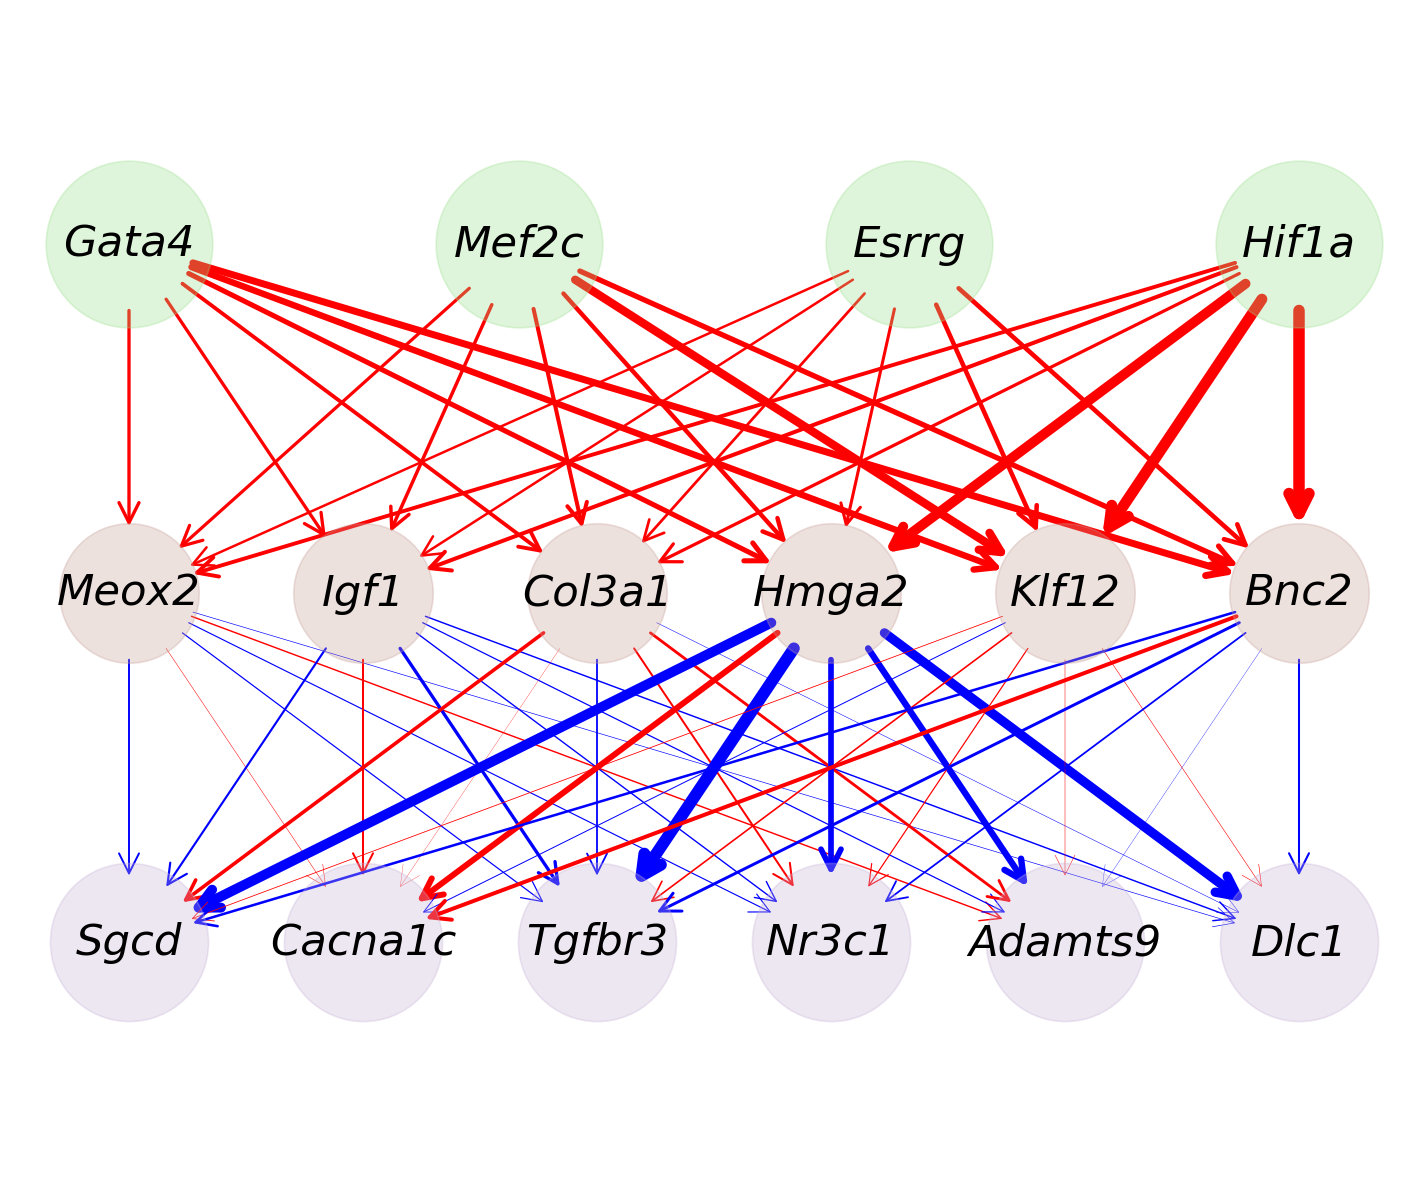

In [6]:
edges, edge_colors, edge_weights, edge_df = collect_edges(INFERRED_DIR)
out_pdf = FIGURE_DIR / '01_three_layer_cardiac_reprogramming_network.pdf'
plot_three_layer_network(edges, edge_colors, edge_weights, out_pdf)



## Biological readout summary

We export full and ranked edge tables so strong positive and negative links can be prioritized for experimental follow-up, including tests of whether inhibiting pro-fibrotic nodes improves cardiac conversion efficiency.

In [7]:
if edge_df.empty:
    raise ValueError('No edges found from inferred outputs.')

edge_table_path = SUMMARY_DIR / '01_cardiac_reprogramming_edges_all.csv'
positive_path = SUMMARY_DIR / '01_top_positive_edges.csv'
negative_path = SUMMARY_DIR / '01_top_negative_edges.csv'

edge_df.to_csv(edge_table_path, index=False)
positive_df = edge_df.sort_values('total_change', ascending=False).head(12).reset_index(drop=True)
negative_df = edge_df.sort_values('total_change', ascending=True).head(12).reset_index(drop=True)
positive_df.to_csv(positive_path, index=False)
negative_df.to_csv(negative_path, index=False)
